<div style="text-align: center; padding: 30px; background-color: #f5f7fa; border-radius: 12px; box-shadow: 0px 4px 10px rgba(0,0,0,0.1);">

  <h1 style="color: #2c3e50; font-family: 'Helvetica Neue', sans-serif; font-size: 42px; margin-bottom: 10px;">
    Protein Bioinformatics
  </h1>

  <h3 style="color: #7f8c8d; font-family: 'Georgia', serif; font-weight: normal; font-size: 22px; margin-top: 0;">
    MidTerm Assessment
  </h3>

  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 16px; margin-top: 20px;">
    Author: <b>Vallari Eastman</b> <br>
    Due Date: <b>Monday October 27th, 2025 11:59 p.m. ET</b>
  </p>
</div>

<div style="padding: 35px; background-color: #f5f7fa; border-radius: 16px; box-shadow: 0px 6px 14px rgba(0,0,0,0.1); margin-bottom: 30px;">

  <h3 style="text-align: center; color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:25px; margin-top:0;">
    Part 1:
  </h3>

<div style="text-align: left; background-color:#f8f9fb; padding:20px; border-radius:10px;">
<p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
    1. Describe how you can potentially calculate the phi and psi dihedral angles, as defined by the IUPAC standards, using the coordinates of the backbone atoms from the PDB file. Specifically, use figures, equations, and code to demonstrate a viable calculation and validation strategy. <br><br>
    2. Describe a strategy for assigning secondary structure based on phi and psi angles. You should assign the secondary structure type for each residue, given the backbone coordinates of the PDB file. The classification should be based on the phi and psi angles of the residue from the steps determined in Question 1; you may use the idea of a Ramachandran plot to define your assignment criteria. Here, a classification in three groups (alpha, beta, other) would be sufficient.  Implement a program that can assign the secondary structure type for each residue given the backbone coordinates of a PDB file. Show annotated program code and relevant outputs from the code.<br><br>
    3. Take a detailed look at the assignment of secondary structure by your program. Inspect your protein through the molecular visualization software of your choice. Specifically, consider the length of the secondary structure elements. You may also compare your secondary structure assignment to the output of the DSSP.  Show images and analysis of all of your secondary structure exploration. Do you find common supersecondary structures? Motifs? Domains? Patches, pockets, or other surface properties? How can your analysis be linked to the function of the protein?<br><br>
    4. Show an example of a secondary structure element assigned by the program that seems incorrect to you. Discuss the quality of your results and possible problems. Suggest improvements to your assignment strategy (to overcome these problems). Be specific regarding the parameters used, statistical approaches, and evaluation criteria.
</p>
</div>

# a. Clean PDB (PDB ID: 7EU8, Chain A only)

In [56]:
# Fetchs 7EU8.pdb using BioPython, parses, extracts Chain A, cleans ChainA (no waters or heteroatoms), and saves files
from pathlib import Path
from Bio.PDB import PDBList, PDBParser, Select, PDBIO

# --- Setup ---
BASE_DIR = Path("/Users/val/Projects/Protein-Bioinformatics/midterm")
BASE_DIR.mkdir(parents=True, exist_ok=True)

pdb_id = "7EU8"
raw_pdb = BASE_DIR / f"{pdb_id}.pdb"
chainA_pdb = BASE_DIR / f"{pdb_id}_chainA.pdb"
chainA_clean = BASE_DIR / f"{pdb_id}_chainA_clean.pdb"

# --- Step 1: Download PDB using BioPython ---
pdbl = PDBList()
pdb_id = '7EU8'
file_path = pdbl.retrieve_pdb_file(pdb_id, pdir=BASE_DIR, file_format='pdb')
print(f"Downloaded PDB file for {pdb_id} to: {file_path}")


# --- Step 2: Parse structure ---
parser = PDBParser(QUIET=True)
structure = parser.get_structure(pdb_id, downloaded)

# --- Step 3: Extract Chain A using BioPython ---
class ChainSelect(Select):
    def __init__(self, chain_id):
        self.chain_id = chain_id
    def accept_chain(self, chain):
        return chain.id == self.chain_id

# --- Step 4: Clean Chain A (no waters or heteroatoms) ---
class CleanChainSelect(Select):
    def __init__(self, chain_id):
        self.chain_id = chain_id
    def accept_chain(self, chain):
        return chain.id == self.chain_id
    def accept_residue(self, residue):
        het, resseq, icode = residue.id
        return het == " "  # keep only standard residues

# --- Step 5: Save both versions ---
io = PDBIO()
io.set_structure(structure)
io.save(str(chainA_pdb), select=ChainSelect("A"))
io.save(str(chainA_clean), select=CleanChainSelect("A"))

print(f"Saved:\n- {chainA_pdb}\n- {chainA_clean}")

Desired structure doesn't exist
Downloaded PDB file for 7EU8 to: /Users/val/Projects/Protein-Bioinformatics/midterm/pdb7eu8.ent
Saved:
- /Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA.pdb
- /Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA_clean.pdb


In [57]:
# Prints the cleaned ChainA sequence (fasta format)
from Bio.PDB import PDBParser, PPBuilder
from IPython.display import HTML, display
from pathlib import Path

# Path to your cleaned chain A file
pdb_path = Path("/Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA_clean.pdb")

# Parse structure and build polypeptides
parser = PDBParser(QUIET=True)
structure = parser.get_structure("7EU8", str(pdb_path))
ppb = PPBuilder()  # ✅ Corrected here

# Extract sequence(s)
seqs = [pp.get_sequence() for pp in ppb.build_peptides(structure)]
sequence = "".join(str(s) for s in seqs)  # Combine fragments

# Display in scrollable light-mode box
display(HTML(f"""
<div style="
    max-height:200px;
    overflow-y:auto;
    border:1px solid #ccc;
    border-radius:8px;
    padding:10px;
    font-family: ui-monospace, Menlo, Consolas, monospace;
    font-size:14px;
    background:#ffffff;
    color:#222;
    line-height:1.5;
    word-wrap:break-word;
">
<b>7EU8 Chain A sequence ({len(sequence)} residues)</b><br>
{sequence}
</div>
"""))


In [58]:
from Bio.PDB import PDBParser, PPBuilder
from pathlib import Path

# Input/output paths
pdb_path = Path("/Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA.pdb")
fasta_out = pdb_path.with_suffix(".fasta")

# Parse structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("7EU8", str(pdb_path))
ppb = PPBuilder()

# Extract sequence(s)
seqs = [pp.get_sequence() for pp in ppb.build_peptides(structure)]
sequence = "".join(str(s) for s in seqs)

# Write FASTA
with open(fasta_out, "w") as f:
    f.write(f">7EU8_chainA\n{sequence}\n")

print(f" FASTA written to: {fasta_out}")

 FASTA written to: /Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA.fasta


# b. Compute Phi and Psi Angles 

In [1]:
# Computes phi and psi, then prints it to a table with formula explainations 
import mdtraj as md
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import HTML, display
from Bio.PDB import PDBParser

# -------------------------------------------------
# paths
# -------------------------------------------------
BASE_DIR = Path("/Users/val/Projects/Protein-Bioinformatics/midterm")
clean_pdb = BASE_DIR / "7EU8_chainA_clean.pdb"
out_csv = BASE_DIR / "7EU8_chainA_phi_psi.csv"

# -------------------------------------------------
# load structure with MDTraj
# -------------------------------------------------
traj = md.load_pdb(str(clean_pdb))
top = traj.topology

# -------------------------------------------------
# compute backbone torsions
# -------------------------------------------------
phi_indices, phi_values = md.compute_phi(traj)   # radians
psi_indices, psi_values = md.compute_psi(traj)   # radians

phi_rad = phi_values[0]        # radians
psi_rad = psi_values[0]
phi_deg = np.degrees(phi_rad)  # degrees
psi_deg = np.degrees(psi_rad)

# -------------------------------------------------
# helper to build human-readable block for each dihedral
# -------------------------------------------------
def explained_dihedral(atom_indices, angle_rad, angle_deg):
    """
    Returns HTML block:

    C-28 = 241 | N-29 = 245 | CA-29 = 247 | C-29 = 250
    θ = dihedral(241, 245, 247, 250) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -1.08 rad
    (-1.08 × 180/π = -62.14°)
    """
    if atom_indices is None or np.isnan(angle_rad) or np.isnan(angle_deg):
        return ""

    atoms = [top.atom(int(a)) for a in atom_indices]

    # Line 1: map atom name/res -> PDB serial
    labeled_parts = []
    serial_ids = []
    for a in atoms:
        labeled_parts.append(f"{a.name}-{a.residue.resSeq} = {a.serial}")
        serial_ids.append(str(a.serial))
    line1 = " | ".join(labeled_parts)

    # Line 2: state the dihedral definition with atan2 reference and radian value
    serial_list = ", ".join(serial_ids)
    line2 = (
        f"θ = dihedral({serial_list}) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) "
        f"= {angle_rad:.2f} rad"
    )

    # Line 3: explicit rad→deg conversion
    line3 = f"({angle_rad:.2f} × 180/π = {angle_deg:.2f}°)"

    return f"{line1}<br>{line2}<br>{line3}"

# -------------------------------------------------
# build table rows
# -------------------------------------------------
rows = []
for i in range(len(phi_indices)):
    phi_quad = phi_indices[i]

    # residue for row = residue owning the N atom (2nd atom of φ quadruplet)
    res_for_row = top.atom(int(phi_quad[1])).residue
    resid = res_for_row.resSeq
    resname = res_for_row.name

    # φ angles
    this_phi_rad = float(phi_rad[i]) if i < len(phi_rad) else np.nan
    this_phi_deg = float(phi_deg[i]) if i < len(phi_deg) else np.nan

    # ψ angles (ψ may be undefined at C-terminus)
    if i < len(psi_indices):
        psi_quad = psi_indices[i]
        this_psi_rad = float(psi_rad[i]) if i < len(psi_rad) else np.nan
        this_psi_deg = float(psi_deg[i]) if i < len(psi_deg) else np.nan
    else:
        psi_quad = None
        this_psi_rad = np.nan
        this_psi_deg = np.nan

    # human-readable blocks
    phi_block = explained_dihedral(phi_quad, this_phi_rad, this_phi_deg)
    psi_block = explained_dihedral(psi_quad, this_psi_rad, this_psi_deg)

    rows.append({
        "pdb_resid": resid,
        "resname": resname,
        "phi_explained": phi_block,
        "psi_explained": psi_block,
        "phi_deg": round(this_phi_deg, 2) if not np.isnan(this_phi_deg) else np.nan,
        "psi_deg": round(this_psi_deg, 2) if not np.isnan(this_psi_deg) else np.nan,
    })

df = pd.DataFrame(rows)

# -------------------------------------------------
# save CSV
# -------------------------------------------------
df.to_csv(out_csv, index=False)
print(f"[info] wrote {out_csv}")

# -------------------------------------------------
# chain sanity check (BioPython parse of same file)
# -------------------------------------------------
parser = PDBParser(QUIET=True)
structure = parser.get_structure("7EU8_chainA", str(clean_pdb))

chains = [
    (
        chain.id,
        len([res for res in chain.get_residues() if res.id[0] == " "])
    )
    for model in structure
    for chain in model
]
print("Chains and (# aa residues):", chains)

first10 = []
for model in structure:
    for chain in model:
        if chain.id == "A":
            for res in chain.get_residues():
                if res.id[0] == " ":  # standard residue only
                    first10.append((res.id[1], res.resname))
                if len(first10) >= 10:
                    break
print("First visible residues in chain A:", first10)

# -------------------------------------------------
# scrollable light-mode display
# -------------------------------------------------
scroll_html = df.to_html(index=False, escape=False)
display(HTML(f"""
<div style="
    max-height:400px;
    overflow-y:auto;
    border:1px solid #ccc;
    border-radius:8px;
    padding:10px;
    font-family: ui-monospace, Menlo, Consolas, monospace;
    font-size:13px;
    background:#ffffff;
    color:#222;
    box-shadow:0 1px 4px rgba(0,0,0,0.08);
    line-height:1.4;
    white-space:nowrap;
">
{scroll_html}
</div>
"""))


[info] wrote /Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA_phi_psi.csv
Chains and (# aa residues): [('A', 761)]
First visible residues in chain A: [(28, 'ASN'), (29, 'ILE'), (30, 'GLY'), (31, 'ALA'), (32, 'VAL'), (33, 'LEU'), (34, 'SER'), (35, 'THR'), (36, 'ARG'), (37, 'LYS')]


pdb_resid,resname,phi_explained,psi_explained,phi_deg,psi_deg
29,ILE,"C-28 = 3 | N-29 = 6 | CA-29 = 7 | C-29 = 8θ = dihedral(3, 6, 7, 8) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -2.21 rad(-2.21 × 180/π = -126.64°)","N-28 = 1 | CA-28 = 2 | C-28 = 3 | N-29 = 6θ = dihedral(1, 2, 3, 6) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -0.30 rad(-0.30 × 180/π = -17.24°)",-126.64,-17.24
30,GLY,"C-29 = 8 | N-30 = 11 | CA-30 = 12 | C-30 = 13θ = dihedral(8, 11, 12, 13) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -1.14 rad(-1.14 × 180/π = -65.06°)","N-29 = 6 | CA-29 = 7 | C-29 = 8 | N-30 = 11θ = dihedral(6, 7, 8, 11) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = 3.06 rad(3.06 × 180/π = 175.12°)",-65.06,175.12
31,ALA,"C-30 = 13 | N-31 = 15 | CA-31 = 16 | C-31 = 17θ = dihedral(13, 15, 16, 17) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -1.25 rad(-1.25 × 180/π = -71.43°)","N-30 = 11 | CA-30 = 12 | C-30 = 13 | N-31 = 15θ = dihedral(11, 12, 13, 15) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = 2.52 rad(2.52 × 180/π = 144.42°)",-71.43,144.42
32,VAL,"C-31 = 17 | N-32 = 20 | CA-32 = 21 | C-32 = 22θ = dihedral(17, 20, 21, 22) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -2.14 rad(-2.14 × 180/π = -122.67°)","N-31 = 15 | CA-31 = 16 | C-31 = 17 | N-32 = 20θ = dihedral(15, 16, 17, 20) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = 2.59 rad(2.59 × 180/π = 148.27°)",-122.67,148.27
33,LEU,"C-32 = 22 | N-33 = 27 | CA-33 = 28 | C-33 = 29θ = dihedral(22, 27, 28, 29) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -2.61 rad(-2.61 × 180/π = -149.33°)","N-32 = 20 | CA-32 = 21 | C-32 = 22 | N-33 = 27θ = dihedral(20, 21, 22, 27) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = 2.23 rad(2.23 × 180/π = 127.79°)",-149.33,127.79
34,SER,"C-33 = 29 | N-34 = 32 | CA-34 = 33 | C-34 = 34θ = dihedral(29, 32, 33, 34) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -1.47 rad(-1.47 × 180/π = -84.27°)","N-33 = 27 | CA-33 = 28 | C-33 = 29 | N-34 = 32θ = dihedral(27, 28, 29, 32) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = 2.78 rad(2.78 × 180/π = 159.06°)",-84.27,159.06
35,THR,"C-34 = 34 | N-35 = 37 | CA-35 = 38 | C-35 = 39θ = dihedral(34, 37, 38, 39) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -1.79 rad(-1.79 × 180/π = -102.44°)","N-34 = 32 | CA-34 = 33 | C-34 = 34 | N-35 = 37θ = dihedral(32, 33, 34, 37) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -1.01 rad(-1.01 × 180/π = -57.63°)",-102.44,-57.63
36,ARG,"C-35 = 39 | N-36 = 42 | CA-36 = 43 | C-36 = 44θ = dihedral(39, 42, 43, 44) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -1.14 rad(-1.14 × 180/π = -65.22°)","N-35 = 37 | CA-35 = 38 | C-35 = 39 | N-36 = 42θ = dihedral(37, 38, 39, 42) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = 2.99 rad(2.99 × 180/π = 171.12°)",-65.22,171.12
37,LYS,"C-36 = 44 | N-37 = 47 | CA-37 = 48 | C-37 = 49θ = dihedral(44, 47, 48, 49) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -1.11 rad(-1.11 × 180/π = -63.50°)","N-36 = 42 | CA-36 = 43 | C-36 = 44 | N-37 = 47θ = dihedral(42, 43, 44, 47) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -0.71 rad(-0.71 × 180/π = -40.69°)",-63.50,-40.69
38,HIS,"C-37 = 49 | N-38 = 52 | CA-38 = 53 | C-38 = 54θ = dihedral(49, 52, 53, 54) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -1.11 rad(-1.11 × 180/π = -63.66°)","N-37 = 47 | CA-37 = 48 | C-37 = 49 | N-38 = 52θ = dihedral(47, 48, 49, 52) using θ = atan2(b₂ᵤ · (n₁ × n₂), n₁ · n₂) = -0.72 rad(-0.72 × 180/π = -41.11°)",-63.66,-41.11


# c. Using Spider2 for Validation

<b>Note: SPIDER3 Server down</b>

# d. STRIDE Data

In [4]:
# STRIDE data taken from web-based STRIDE application; this code cleans the file and prints
import re
import pandas as pd
from pathlib import Path
from IPython.display import HTML, display  # needed for scrollable preview

stride_path = Path("/Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_STRIDE.txt")

rows = []
num_re = re.compile(r"[-+]?\d*\.\d+|\d+")

with open(stride_path, "r") as fh:
    for line in fh:
        # STRIDE secondary structure assignments are on lines that start with "ASG"
        if not line.startswith("ASG"):
            continue

        # Parse using fixed-width substrings (STRIDE format)
        resname = line[4:7].strip()          # residue name, e.g. ASN
        chain   = line[8:9].strip()          # chain ID, e.g. A
        pdb_res = line[10:15].strip()        # PDB residue number, e.g. 28
        seq_idx = line[16:21].strip()        # sequential index in chain
        ss_code = line[24:25].strip()        # 1-letter SS code (H,E,C,…)
        ss_full = line[27:43].strip()        # full SS label (AlphaHelix, Coil, etc.)

        phi_txt = line[44:53].strip()        # phi in degrees
        psi_txt = line[54:63].strip()        # psi in degrees
        area_txt= line[64:].strip()          # solvent exposure-ish

        # helper to robustly grab first number from the field
        def safe_float(x):
            m = num_re.findall(x)
            return float(m[0]) if m else None

        rows.append({
            "seq_idx": int(seq_idx),
            "pdb_resid": int(pdb_res),
            "resname": resname,
            "chain": chain,
            "ss_code_stride": ss_code,
            "ss_full_stride": ss_full,
            "phi_deg_stride": safe_float(phi_txt),
            "psi_deg_stride": safe_float(psi_txt),
            "accessibility": safe_float(area_txt),
        })

# turn into DataFrame and sort by PDB residue number
df_stride = (
    pd.DataFrame(rows)
    .sort_values("pdb_resid")
    .reset_index(drop=True)
)

# save full table to CSV
out_csv = Path("/Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA_STRIDE_per_residue.csv")
df_stride.to_csv(out_csv, index=False)
print(f"[info] wrote {out_csv} ({len(df_stride)} residues)")

# scrollable, light-mode preview of first 50 rows
display(HTML(f"""
<div style="
    max-height:400px;
    overflow-y:auto;
    border:1px solid #ccc;
    border-radius:8px;
    padding:10px;
    font-family: ui-monospace, Menlo, Consolas, monospace;
    font-size:12px;
    background:#fff;
    color:#222;
    line-height:1.4;
    white-space:nowrap;">
{df_stride.head(50).to_html(index=False)}
</div>
"""))

[info] wrote /Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA_STRIDE_per_residue.csv (761 residues)


seq_idx,pdb_resid,resname,chain,ss_code_stride,ss_full_stride,phi_deg_stride,psi_deg_stride,accessibility
1,28,AS,,C,Coil,60.00,17.24,66.8
2,29,IL,,C,Coil -,26.64,75.12,15.1
3,30,GL,,C,Coil,65.06,44.42,14.7
4,31,AL,,C,Coil,71.43,48.27,42.6
5,32,VA,,C,Coil -,22.67,27.79,28.9
6,33,LE,,C,Coil -,49.33,59.06,20.3
7,34,SE,,C,Coil,84.27,57.63,56.7
8,35,TH,,C,Coil -,2.44,71.12,60.6
9,36,AR,,H,AlphaHelix,65.22,40.69,85.1
10,37,LY,,H,AlphaHelix,63.50,41.11,78.0


In [13]:
# STRIDE Secondary Structure Prediction
helix_res = df_stride.loc[df_stride["ss_code_stride"] == "H", "pdb_resid"].tolist()
sheet_res = df_stride.loc[df_stride["ss_code_stride"] == "E", "pdb_resid"].tolist()
coil_res  = df_stride.loc[~df_stride["ss_code_stride"].isin(["H","E"]), "pdb_resid"].tolist()

def ranges(nums):
    # turn [36,37,38,39,41,42] -> ['36-39','41-42']
    if not nums:
        return []
    nums = sorted(nums)
    start = prev = nums[0]
    out = []
    for n in nums[1:]:
        if n == prev + 1:
            prev = n
        else:
            out.append(f"{start}-{prev}" if start != prev else f"{start}")
            start = prev = n
    out.append(f"{start}-{prev}" if start != prev else f"{start}")
    return out

helix_ranges = ranges(helix_res)
sheet_ranges = ranges(sheet_res)
coil_ranges  = ranges(coil_res)

print("Helix ranges:", helix_ranges)
print("Sheet ranges:", sheet_ranges)
print("Coil ranges:", coil_ranges)

Helix ranges: ['36-52', '71-85', '104-113', '126-131', '148-158', '171-184', '205-214', '225-238', '256-261', '279-297', '317-327', '458-470', '560-582', '604-612', '631-656', '670-673', '688-694', '700-705', '714-723', '733-743', '768-782', '784-795', '810-840']
Sheet ranges: ['118-120', '137-139', '163-167', '218-222', '247-249', '266-271', '350-357', '360-368', '397-401', '409-413', '434-437', '452-457', '473-477', '486-488', '497-499', '532-543', '728-730', '746-759']
Coil ranges: ['28-35', '58-70', '86-103', '114-117', '121-125', '132-136', '140-147', '159-162', '168-170', '185-186', '189-204', '215-217', '223-224', '239-246', '250-255', '262-265', '272-278', '298-316', '328-349', '358-359', '369-396', '402-408', '414-433', '438-451', '471-472', '478-485', '489', '496', '500-531', '544-545', '552-559', '603', '613-618', '626-630', '657-669', '674-687', '695-699', '706-713', '724-727', '731-732', '744-745', '760-767', '783', '796-799', '807-809', '841']


# e. DSSP Data

In [6]:
# DSSP data taken from web-based DSSP application; this parsers the .dssp file
import re
import pandas as pd
from pathlib import Path
import math

float_re = re.compile(r"[-+]?\d+\.\d+|[-+]?\d+(?=\s)")  
# explanation:
# - match signed floats like -65.4
# - OR signed ints like 360 (but avoid gluing trailing commas etc.)

def parse_dssp_legacy_regex(dssp_path):
    rows = []
    in_table = False

    with open(dssp_path, "r") as fh:
        for raw in fh:
            line = raw.rstrip("\n")

            # detect header boundary
            if line.lstrip().startswith("#  RESIDUE AA STRUCTURE"):
                in_table = True
                continue
            if not in_table:
                continue

            # skip non-residue lines
            if not re.match(r"\s*\d+", line):
                continue

            # --- fixed-width "front" ---
            dssp_idx_str  = line[0:5].strip()    # DSSP serial
            pdb_resid_str = line[5:10].strip()   # PDB residue number
            chain_id      = line[10:12].strip()  # chain
            aa            = line[12:15].strip()  # amino acid
            struct_block  = line[16:25]          # DSSP structure descriptor
            acc_str       = line[34:38].strip()  # Accessible surface area

            if aa == "!":    # chain break marker
                continue

            # convert indices
            try:
                dssp_idx = int(dssp_idx_str)
            except ValueError:
                continue

            try:
                pdb_resid = int(pdb_resid_str)
            except ValueError:
                continue

            sb_clean = struct_block.strip()
            primary_code = sb_clean[0] if sb_clean else ""

            # accessible surface area
            try:
                acc_val = float(acc_str)
            except ValueError:
                acc_val = math.nan

            # --- tail numeric parse using regex ---
            tail_txt = line[38:]
            # grab ALL numbers in order, including glued negatives
            nums = float_re.findall(tail_txt)

            # convert all to float
            try:
                nums = [float(x) for x in nums]
            except ValueError:
                nums = []

            # We expect ... TCO, KAPPA, ALPHA, PHI, PSI, Xca, Yca, Zca
            phi_val = math.nan
            psi_val = math.nan
            if len(nums) >= 5:
                phi_val = nums[-5]
                psi_val = nums[-4]

            rows.append({
                "dssp_idx": dssp_idx,
                "pdb_resid": pdb_resid,
                "chain": chain_id,
                "aa": aa,
                "dssp_code": primary_code,
                "dssp_block": sb_clean,
                "acc": acc_val,
                "phi_deg_dssp": phi_val,
                "psi_deg_dssp": psi_val,
            })

    return pd.DataFrame(rows)

# Run it
dssp_file = Path("/Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_DSSPLegacy.dssp")
df_dssp = parse_dssp_legacy_regex(dssp_file)

print("Parsed rows:", len(df_dssp))
display(df_dssp.head(15))

Parsed rows: 761


,dssp_idx,pdb_resid,chain,aa,dssp_code,dssp_block,acc,phi_deg_dssp,psi_deg_dssp
0,1,28,A,N,,,66.0,360.0,-17.2
1,2,29,A,I,-,-,14.0,-126.6,175.1
2,3,30,A,G,-,-,14.0,-65.1,144.4
3,4,31,A,A,-,-,43.0,-71.4,148.3
4,5,32,A,V,+,+,29.0,-122.7,127.8
5,6,33,A,L,-,-,21.0,-149.3,159.1
6,7,34,A,S,S,S S+,57.0,-84.3,-57.6
7,8,35,A,T,S,S > S-,59.0,-102.4,171.1
8,9,36,A,R,H,H > S+,87.0,-65.2,-40.7
9,10,37,A,K,H,H > S+,79.0,-63.5,-41.1


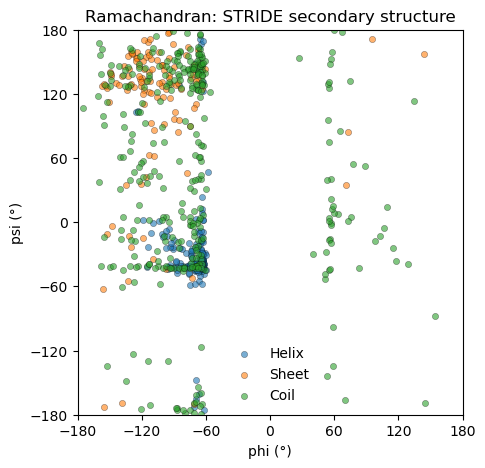

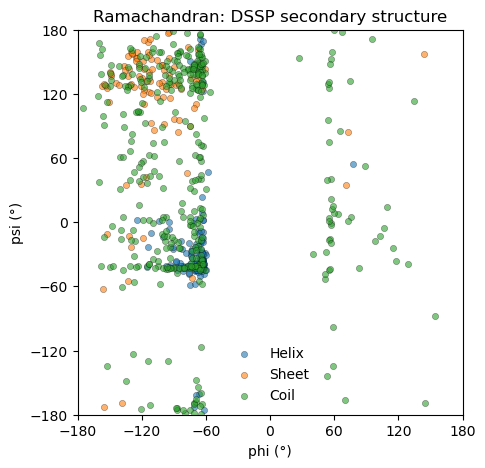

In [14]:
# Ramachandran colored by DSSP class
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# assume `merged` DataFrame is already in memory from the previous step
# and has columns:
# phi_mdtraj_deg, psi_mdtraj_deg, ss_stride, ss_dssp

def classify_stride(ss):
    """
    Collapse STRIDE's ss label into Helix / Sheet / Coil
    e.g. 'AlphaHelix', '310Helix', etc → Helix
         'Strand', 'Bridge' → Sheet
         else → Coil
    """
    if pd.isna(ss):
        return "Coil"
    s = ss.lower()
    if "helix" in s:
        return "Helix"
    if "strand" in s or "sheet" in s or "bridge" in s:
        return "Sheet"
    return "Coil"

def classify_dssp(code):
    """
    DSSP 1-letter code:
    H = alpha helix
    G = 3-10 helix
    I = pi helix
    E = extended strand
    B = beta bridge
    T, S, ' ' = turn/bend/loop/etc.
    """
    if pd.isna(code) or code.strip() == "":
        return "Coil"
    c = code.strip()[0]
    if c in ["H", "G", "I"]:
        return "Helix"
    if c in ["E", "B"]:
        return "Sheet"
    return "Coil"

plot_df = merged.copy()

plot_df["ss3_stride"] = plot_df["ss_stride"].apply(classify_stride)
plot_df["ss3_dssp"]   = plot_df["ss_dssp"].apply(classify_dssp)

# We'll also drop rows that don't have angles
plot_df = plot_df[
    ~plot_df["phi_mdtraj_deg"].isna() &
    ~plot_df["psi_mdtraj_deg"].isna()
].reset_index(drop=True)

# helper to make the plot
def rama_plot(df, ss_col, title):
    fig, ax = plt.subplots(figsize=(5,5))
    
    # split by class to get per-class scatter (easier legend)
    for ss_class in ["Helix", "Sheet", "Coil"]:
        sub = df[df[ss_col] == ss_class]
        ax.scatter(
            sub["phi_mdtraj_deg"],
            sub["psi_mdtraj_deg"],
            s=20,
            alpha=0.6,
            label=ss_class,
            edgecolors='black',
            linewidths=0.3
        )
    
    ax.set_xlabel("phi (°)")
    ax.set_ylabel("psi (°)")
    ax.set_title(title)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.set_yticks(np.arange(-180, 181, 60))
    ax.set_aspect('equal', 'box')
    ax.legend(frameon=False, loc="best")
    plt.show()

# 1) Ramachandran colored by STRIDE
rama_plot(plot_df, "ss3_stride", "Ramachandran: STRIDE secondary structure")

# 2) Ramachandran colored by DSSP
rama_plot(plot_df, "ss3_dssp", "Ramachandran: DSSP secondary structure")

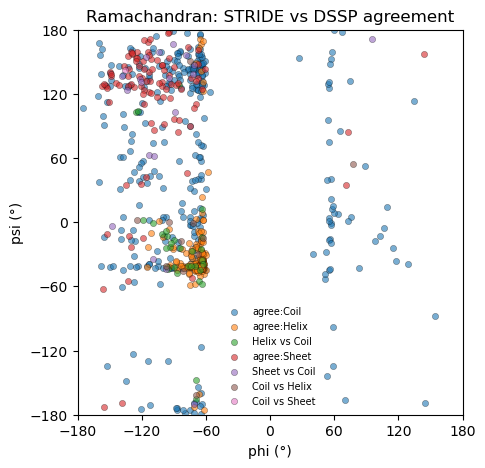

In [15]:
# Ramachandran showing disagreements between DSSP and STRIDE
def disagreement_label(row):
    a = row["ss3_stride"]
    b = row["ss3_dssp"]
    if a == b:
        return "agree:" + a
    return f"{a} vs {b}"

plot_df["agreement_state"] = plot_df.apply(disagreement_label, axis=1)

fig, ax = plt.subplots(figsize=(5,5))

for state in plot_df["agreement_state"].unique():
    sub = plot_df[plot_df["agreement_state"] == state]
    ax.scatter(
        sub["phi_mdtraj_deg"],
        sub["psi_mdtraj_deg"],
        s=20,
        alpha=0.6,
        label=state,
        edgecolors='black',
        linewidths=0.3
    )

ax.set_xlabel("phi (°)")
ax.set_ylabel("psi (°)")
ax.set_title("Ramachandran: STRIDE vs DSSP agreement")
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_xticks(np.arange(-180, 181, 60))
ax.set_yticks(np.arange(-180, 181, 60))
ax.set_aspect('equal', 'box')
ax.legend(frameon=False, fontsize=7, loc="best")
plt.show()

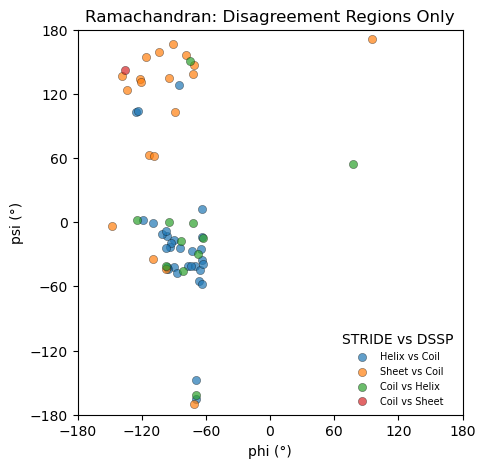

In [19]:
# Plot ONLY disagreements
fig, ax = plt.subplots(figsize=(5, 5))

for mismatch in disagree_df["disagreement"].unique():
    sub = disagree_df[disagree_df["disagreement"] == mismatch]
    ax.scatter(
        sub["phi_mdtraj_deg"],
        sub["psi_mdtraj_deg"],
        s=35,
        alpha=0.7,
        label=mismatch,
        edgecolors="black",
        linewidths=0.3
    )

ax.set_xlabel("phi (°)")
ax.set_ylabel("psi (°)")
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_xticks(np.arange(-180, 181, 60))
ax.set_yticks(np.arange(-180, 181, 60))
ax.set_aspect('equal', 'box')
ax.legend(frameon=False, fontsize=7, loc="best", title="STRIDE vs DSSP")
ax.set_title("Ramachandran: Disagreement Regions Only")

plt.show()

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming `plot_df` has your columns from before:
# phi_mdtraj_deg, psi_mdtraj_deg, ss3_stride, ss3_dssp

# Identify disagreements
disagree_df = plot_df[
    plot_df["ss3_stride"] != plot_df["ss3_dssp"]
].copy()

# Count how many
print(f"Residues with disagreement: {len(disagree_df)} / {len(plot_df)} total")

# Build a descriptive column for labeling
disagree_df["disagreement"] = (
    disagree_df["ss3_stride"].astype(str) + " vs " + disagree_df["ss3_dssp"].astype(str)
)

# Quick summary of how many of each type of disagreement
summary = disagree_df["disagreement"].value_counts().reset_index()
summary.columns = ["Disagreement Type", "Count"]
display(summary.head(10))

# Optional: print the specific residues where this happens
print("\nResidues with disagreement:")
print(disagree_df[["pdb_resid", "resname", "ss3_stride", "ss3_dssp"]]
      .to_string(index=False))

Residues with disagreement: 62 / 760 total


,Disagreement Type,Count
0,Helix vs Coil,31
1,Sheet vs Coil,19
2,Coil vs Helix,11
3,Coil vs Sheet,1



Residues with disagreement:
 pdb_resid resname ss3_stride ss3_dssp
        52     ARG      Helix     Coil
       104     PRO      Helix     Coil
       126     SER      Helix     Coil
       163     ILE      Sheet     Coil
       184     LEU      Helix     Coil
       205     THR      Helix     Coil
       216     ALA      Sheet     Coil
       218     VAL      Sheet     Coil
       238     LEU      Helix     Coil
       279     ALA      Helix     Coil
       297     GLU      Helix     Coil
       317     THR      Helix     Coil
       330     TYR      Sheet     Coil
       338     VAL      Sheet     Coil
       392     TYR      Sheet     Coil
       501     MET      Helix     Coil
       502     MET      Helix     Coil
       503     GLY      Helix     Coil
       506     LEU       Coil    Helix
       507     SER       Coil    Helix
       528     GLU      Sheet     Coil
       532     PRO      Sheet     Coil
       533     PHE      Sheet     Coil
       538     LEU      Sheet     C

# f. Merge Data

In [11]:
# Merge data into one table/csv
import pandas as pd
from IPython.display import display, HTML
from pathlib import Path

# We assume you already have in memory:
# df         -> mdtraj torsion table (phi/psi from MDTraj)
# df_stride  -> STRIDE table
# df_dssp    -> DSSP table

# --- Step 0. Normalize the mdtraj dataframe `df` defensively ---

md_cols = df.columns.tolist()

# figure out which column is the residue number in PDB
if "pdb_resid" in md_cols:
    resid_col = "pdb_resid"
elif "resid" in md_cols:
    resid_col = "resid"
else:
    # absolute fallback: try something obvious like "resSeq"
    # if this triggers, something is really off but we won't crash
    resid_col = [c for c in md_cols if "res" in c.lower() and "id" in c.lower()][0]

# figure out phi/psi degree column names
if "phi_mdtraj_deg" in md_cols and "psi_mdtraj_deg" in md_cols:
    phi_col = "phi_mdtraj_deg"
    psi_col = "psi_mdtraj_deg"
else:
    # expected original names from the torsion code
    phi_col = "phi_deg"
    psi_col = "psi_deg"

# now safely pull/rename from df
md_trim = df[[resid_col, "resname", phi_col, psi_col]].copy()

md_trim = md_trim.rename(columns={
    resid_col: "pdb_resid",
    phi_col: "phi_mdtraj_deg",
    psi_col: "psi_mdtraj_deg",
})

# make sure pdb_resid is int so merges work nicely
md_trim["pdb_resid"] = md_trim["pdb_resid"].astype(int)


# --- Step 1. Prep STRIDE slice ---

stride_trim = df_stride[[
    "pdb_resid",
    "resname",
    "phi_deg_stride",
    "psi_deg_stride",
    "ss_full_stride",
]].copy()

stride_trim = stride_trim.rename(columns={
    "ss_full_stride": "ss_stride"
})

stride_trim["pdb_resid"] = stride_trim["pdb_resid"].astype(int)


# --- Step 2. Prep DSSP slice ---

dssp_trim = df_dssp[[
    "pdb_resid",
    "aa",
    "dssp_code",
    "acc",
    "phi_deg_dssp",
    "psi_deg_dssp",
]].copy()

dssp_trim = dssp_trim.rename(columns={
    "aa": "resname_dssp",
    "dssp_code": "ss_dssp",
    "acc": "acc_dssp",
})

dssp_trim["pdb_resid"] = dssp_trim["pdb_resid"].astype(int)


# --- Step 3. Merge all three on pdb_resid ---

merged = (
    md_trim
    .merge(dssp_trim, on="pdb_resid", how="left")
    .merge(stride_trim, on="pdb_resid", how="left", suffixes=("", "_stride2"))
)

# --- Step 4. Arrange columns in a nice storytelling order ---

merged = merged[[
    "pdb_resid",
    "resname",            # 3-letter from mdtraj topology
    "resname_dssp",       # 1-letter from DSSP
    "ss_dssp",            # DSSP sec. structure
    "ss_stride",          # STRIDE sec. structure

    "phi_mdtraj_deg",
    "psi_mdtraj_deg",
    "phi_deg_dssp",
    "psi_deg_dssp",
    "phi_deg_stride",
    "psi_deg_stride",

    "acc_dssp",           # DSSP solvent accessibility
]]

# --- Step 5. Save to CSV ---

out_csv = Path("/Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA_angle_compare.csv")
merged.to_csv(out_csv, index=False)
print(f"Saved merged validation table to: {out_csv}")

# --- Step 6 (revised): Pre-format numeric columns and render scrollable light table ---

merged_for_show = merged.copy()

# format numeric columns to 2 decimals as strings so to_html doesn't complain
num_cols = [
    "phi_mdtraj_deg",
    "psi_mdtraj_deg",
    "phi_deg_dssp",
    "psi_deg_dssp",
    "phi_deg_stride",
    "psi_deg_stride",
    "acc_dssp",
]

for col in num_cols:
    if col in merged_for_show.columns:
        merged_for_show[col] = merged_for_show[col].apply(
            lambda x: f"{x:0.2f}" if pd.notna(x) else ""
        )

html_table = merged_for_show.to_html(
    index=False,
    classes="angle-compare-table",
    escape=False
)

style_block = """
<style>
.angle-compare-table {
    border-collapse: collapse;
    font-family: -apple-system, BlinkMacSystemFont, "Inter", "Helvetica Neue", Arial, sans-serif;
    font-size: 12px;
    color: #1a1a1a;
}
.angle-compare-table th {
    position: sticky;
    top: 0;
    background: #fafafa;
    color: #000;
    text-align: center;
    border-bottom: 2px solid #999;
    padding: 6px 8px;
    white-space: nowrap;
    z-index: 2;
}
.angle-compare-table td {
    border-bottom: 1px solid #ddd;
    padding: 4px 8px;
    text-align: right;
    white-space: nowrap;
}
.angle-compare-table td:nth-child(1),
.angle-compare-table td:nth-child(2),
.angle-compare-table td:nth-child(3),
.angle-compare-table td:nth-child(4),
.angle-compare-table td:nth-child(5) {
    text-align: left;
    font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace;
    font-size: 11px;
    color: #000;
}
.scroll-wrap {
    max-height: 400px;
    max-width: 100%;
    overflow-y: scroll;
    overflow-x: scroll;
    border: 1px solid #ccc;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    background: #fff;
    border-radius: 6px;
}
</style>
<div class="scroll-wrap">""" + html_table + "</div>"

display(HTML(style_block))

Saved merged validation table to: /Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA_angle_compare.csv


pdb_resid,resname,resname_dssp,ss_dssp,ss_stride,phi_mdtraj_deg,psi_mdtraj_deg,phi_deg_dssp,psi_deg_dssp,phi_deg_stride,psi_deg_stride,acc_dssp
29,ILE,I,-,Coil -,-126.64,-17.24,-126.60,175.10,26.64,75.12,14.00
30,GLY,G,-,Coil,-65.06,175.12,-65.10,144.40,65.06,44.42,14.00
31,ALA,A,-,Coil,-71.43,144.42,-71.40,148.30,71.43,48.27,43.00
32,VAL,V,+,Coil -,-122.67,148.27,-122.70,127.80,22.67,27.79,29.00
33,LEU,L,-,Coil -,-149.33,127.79,-149.30,159.10,49.33,59.06,21.00
34,SER,S,S,Coil,-84.27,159.06,-84.30,-57.60,84.27,57.63,57.00
35,THR,T,S,Coil -,-102.44,-57.63,-102.40,171.10,2.44,71.12,59.00
36,ARG,R,H,AlphaHelix,-65.22,171.12,-65.20,-40.70,65.22,40.69,87.00
37,LYS,K,H,AlphaHelix,-63.50,-40.69,-63.50,-41.10,63.50,41.11,79.00
38,HIS,H,H,AlphaHelix,-63.66,-41.11,-63.70,-39.70,63.66,39.67,41.00


<b> Color by STRIDE Prediction in PyMol</b>
PyMol Script: 
1. load the structure
load /Users/val/Projects/Protein-Bioinformatics/midterm/7EU8_chainA_clean.pdb, chainA

2. show cartoon for the whole chain
hide everything, chainA
show cartoon, chainA

3.  default all to a neutral light gray/blue so we can recolor regions
set cartoon_color, lightblue
color lightblue, chainA

4. Color by STRIDE Prediction

- HELICES (red)
color red, resi 36-52
color red, resi 71-85
color red, resi 104-113
color red, resi 126-131
color red, resi 148-158
color red, resi 171-184
color red, resi 205-214
color red, resi 225-238
color red, resi 256-261
color red, resi 279-297
color red, resi 317-327
color red, resi 458-470
color red, resi 560-582
color red, resi 604-612
color red, resi 631-656
color red, resi 670-673
color red, resi 688-694
color red, resi 700-705
color red, resi 714-723
color red, resi 733-743
color red, resi 768-782
color red, resi 784-795
color red, resi 810-840

- SHEETS (yellow)
color yellow, resi 118-120
color yellow, resi 137-139
color yellow, resi 163-167
color yellow, resi 218-222
color yellow, resi 247-249
color yellow, resi 266-271
color yellow, resi 350-357
color yellow, resi 360-368
color yellow, resi 397-401
color yellow, resi 409-413
color yellow, resi 434-437
color yellow, resi 452-457
color yellow, resi 473-477
color yellow, resi 486-488
color yellow, resi 497-499
color yellow, resi 532-543
color yellow, resi 728-730
color yellow, resi 746-759

- COILS / LOOPS (green)
color green, resi 28-35
color green, resi 58-70
color green, resi 86-103
color green, resi 114-117
color green, resi 121-125
color green, resi 132-136
color green, resi 140-147
color green, resi 159-162
color green, resi 168-170
color green, resi 185-186
color green, resi 189-204
color green, resi 215-217
color green, resi 223-224
color green, resi 239-246
color green, resi 250-255
color green, resi 262-265
color green, resi 272-278
color green, resi 298-316
color green, resi 328-349
color green, resi 358-359
color green, resi 369-396
color green, resi 402-408
color green, resi 414-433
color green, resi 438-451
color green, resi 471-472
color green, resi 478-485
color green, resi 489
color green, resi 496
color green, resi 500-531
color green, resi 544-545
color green, resi 552-559
color green, resi 603
color green, resi 613-618
color green, resi 626-630
color green, resi 657-669
color green, resi 674-687
color green, resi 695-699
color green, resi 706-713
color green, resi 724-727
color green, resi 731-732
color green, resi 744-745
color green, resi 760-767
color green, resi 783
color green, resi 796-799
color green, resi 807-809
color green, resi 841

5. Visual settings
set cartoon_fancy_helices, on
set cartoon_fancy_sheets, on
set cartoon_transparency, 0.15
set cartoon_side_chain_helper, on
bg_color white
zoom all

<!-- Two figures aligned left and right with spacing -->
<div style="display: flex; justify-content: flex-start; align-items: flex-start; margin-top: 20px;"
    
  <!-- Figure 1 (left) -->
  <div style="width: 50%; margin-right: 60px; background-color: #ffffff; 
              border-radius: 12px; box-shadow: 0px 4px 8px rgba(0,0,0,0.15); padding: 12px;">

  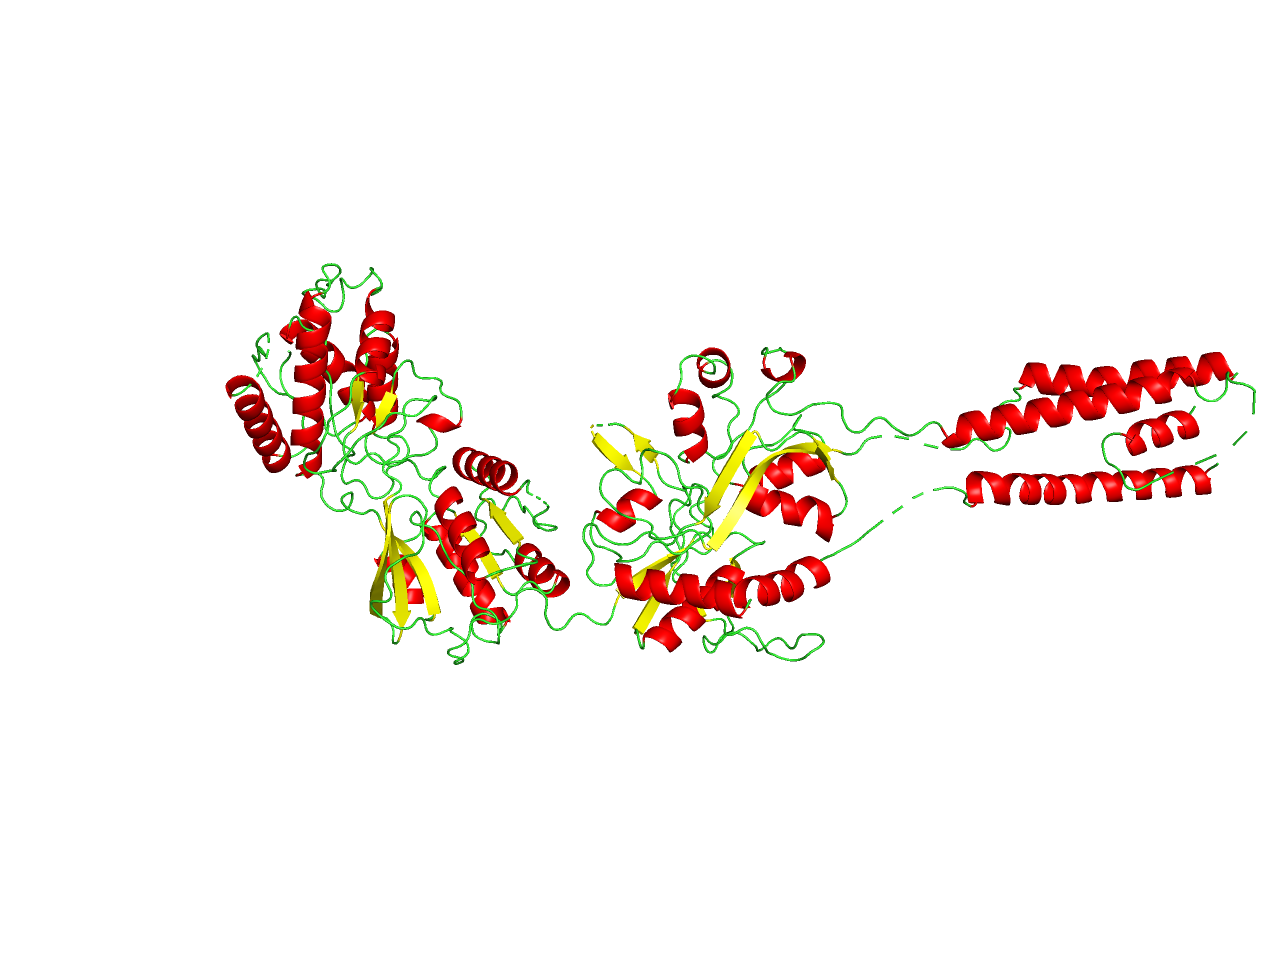

  <p style="font-family: 'Georgia', serif; font-size: 14px; color: #444; margin-top: 10px; text-align: left;">
      <b>Figure 1.</b> NR1 chain A color coded to DSSP Secondary Structure Prediction:</b><br>
      The secondary structure is in 3 colors denoting helices (red), sheets (yellow), and loops (green).
    </p>
  </div>

  <!-- Figure 2 (right) -->
  <div style="width: 50%; background-color: #ffffff; 
              border-radius: 12px; box-shadow: 0px 4px 8px rgba(0,0,0,0.15); padding: 12px;">
      
  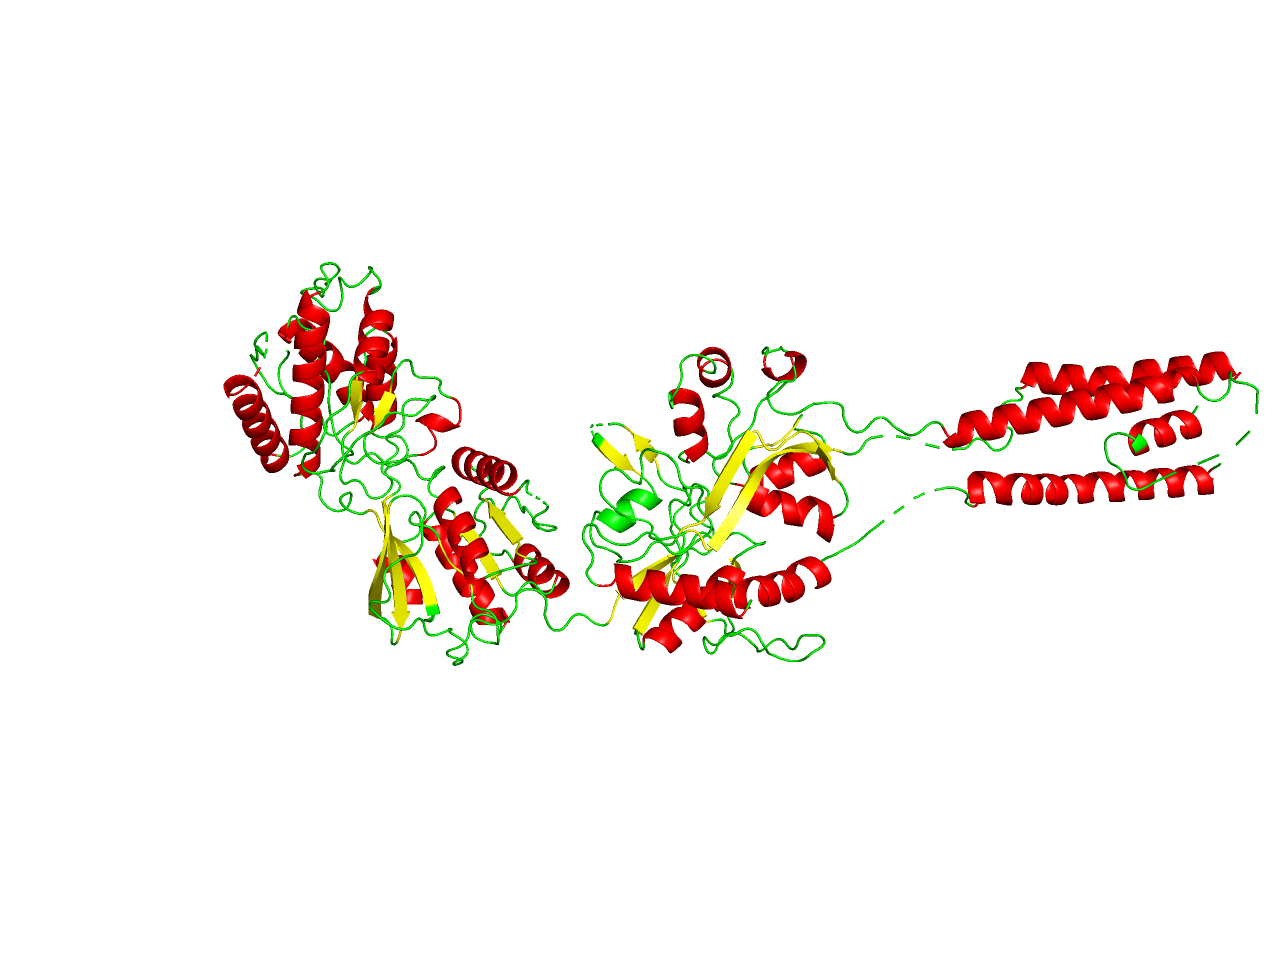

  <p style="font-family: 'Georgia', serif; font-size: 14px; color: #444; margin-top: 10px; text-align: left;">
      <b>Figure 2.</b> NR1 chain A color coded to STRIDE Secondary Structure Prediction:</b><br>
      The structure depicted is the DSSP structure, while the color coding for the secondary structure predicted by STRIDE is in 3 colors denoting helices (red), sheets (yellow), and loops (green). Disagreements are seen when a structure displays a different color than expected (i.e. the helix at residues 501-507, center view, being green, indicating DSSP predicted a helix structure, while STRIDE predicted a loop structure).
    </p>
  </div>
</div>

# Overview of secondary structure content and element length

Using STRIDE, the protein is predicted to contain a series of α-helices distributed across the full chain, including both long helices (>10 residues) and shorter helical turns (5–8 residues). Major helix segments were assigned at residues 36–52, 71–85, 104–113, 148–158, 171–184, 205–214, 225–238, 279–297, 317–327, 458–470, 560–582, 631–656, 714–723, 733–743, 768–782, 784–795, and 810–840, among others. These runs are generally 10–20 residues long, with several helical “clusters” where helices appear back-to-back separated only by a few residues of coil (for example 768–782 immediately followed by 784–795, then later 810–840). This is typical for compact helical bundles or helical arms at the core of a folded domain, where long amphipathic helices pack against each other.

STRIDE also identifies multiple β-strand segments, typically 3–6 residues long, at positions such as 163–167, 218–222, 266–271, 350–357, 360–368, 397–401, 409–413, 434–437, 452–457, 473–477, 532–543, and 746–759. The fact that these are short, discontinuous stretches separated by coil strongly suggests they do not exist as isolated strands; instead they are forming β-sheets through long-range pairing. This pattern (many short strands scattered across the sequence rather than one big β-sandwich block) usually means the fold has at least one β-sheet that is not strictly local in sequence — i.e. strands from different parts of the chain come together in 3D.

All remaining regions are called coil or loop by STRIDE (for example 86–103, 189–204, 298–316, 328–349, 369–396, 500–531, 657–669, 674–687, 706–713, 760–767). A lot of those coil segments are long (15+ residues), not just 3–4 residue turns. Long coil segments are often where domains connect or hinge, and they’re frequently exposed.

Taken together, the secondary structure map is not “all helix” or “all sheet.” It looks like a mixed α/β architecture plus long loops. That is a hallmark of large extracellular or regulatory domains: you get helical bundles, β-sheet cores, and extended loops that mediate binding, flexibility, or conformational change.